# 02 · scVI integration

**Phase 2 of the project** ([PROJECT_PLAN.md](../PROJECT_PLAN.md)).

Train scVI on the filtered LuCA subsample to produce a batch-corrected latent
embedding. `study` (19 levels) is the batch covariate — the strongest source
of nuisance variation across the atlas. The resulting `X_scVI` embedding is
what notebook 03 (cell-type annotation) and notebook 04 (composition
classifier) will build on.

**Why scVI here.** Nineteen labs, nineteen protocols, nineteen instruments
generated this atlas. If we ran PCA → UMAP on the log-normalized matrix, the
largest axes of variation would be *which lab generated the data*, not *what
kind of cell it is*. scVI is a variational autoencoder that explicitly
conditions on the batch covariate while learning the latent space, so
`X_scVI` captures cell-state biology with study effects removed.

**Inputs**: `data/processed/luca_filtered.h5ad` (`.X` = log-normalized,
`layers["counts"]` = raw counts → scVI requires raw counts).
**Outputs**:
- `models/scvi_luca/` — model checkpoint (gitignored)
- `data/processed/luca_integrated.h5ad` — adds `obsm["X_scVI"]` and
  `obsm["X_umap"]`
- `figures/elbo_history.png`, `figures/umap_by_study.png`,
  `figures/umap_by_disease.png`, `figures/umap_by_cell_type_major.png`
- `figures/integration_metrics.csv` (tracked in git)

**Time budget**: ~45–75 min on 4-thread CPU. Section 4 is the only slow cell.

## 1. Setup

In [1]:
import os
import sys
import warnings
import time
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import scvi
import torch

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="lightning")

# Quiet scvi-tools INFO logging (it prints absolute file paths on model load)
scvi.settings.verbosity = logging.WARNING

# Locate the repo root. Launch Jupyter from inside the repo (standard
# workflow); if launching from elsewhere, set the REPO_ROOT env variable.
def _find_repo_root():
    env = os.environ.get("REPO_ROOT")
    if env and (Path(env) / "src" / "subsample.py").exists():
        return Path(env).resolve()
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "subsample.py").exists():
            return p.resolve()
    raise RuntimeError(
        "Repo root not found. Launch Jupyter from inside the repository, "
        "or set the REPO_ROOT environment variable."
    )

ROOT = _find_repo_root()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))


def relpath(p):
    """Path relative to the repo root - keeps printed paths portable."""
    p = Path(p)
    try:
        return p.relative_to(ROOT)
    except ValueError:
        return p.name


from src.data_io import load_adata, save_adata, DATA_DIR

FIG_DIR = ROOT / "figures"
PROC_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models" / "scvi_luca"
FIG_DIR.mkdir(exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.parent.mkdir(parents=True, exist_ok=True)

sc.settings.figdir = "figures"
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.settings.verbosity = 2

torch.set_num_threads(torch.get_num_threads())

print(f"scanpy:     {sc.__version__}")
print(f"anndata:    {ad.__version__}")
print(f"scvi-tools: {scvi.__version__}")
print(f"torch:      {torch.__version__}")
print(f"  threads:  {torch.get_num_threads()}")
print(f"  cuda:     {torch.cuda.is_available()}")
print(f"repo root:  {ROOT.name}/")

scanpy:     1.11.5
anndata:    0.12.14
scvi-tools: 1.4.2
torch:      2.12.0+cpu
  threads:  4
  cuda:     False
repo root:  scrnaseq-tumor-microenvironment/


## 2. Load filtered AnnData + pre-flight

Load the output of notebook 01. Confirm that:
- `.X` is log-normalized (rows sum to ~10–20 once log1p'd)
- `layers["counts"]` carries raw integer-ish counts (matches `obs.total_counts`)
- `obs["study"]` is the batch variable with the expected 19 levels

In [2]:
adata = load_adata("processed/luca_filtered.h5ad")
print(adata)
print()

# Confirm layers["counts"] is raw counts
assert "counts" in adata.layers, "Missing layers['counts'] - did notebook 01 save raw counts?"
sample_sums = np.asarray(adata.layers["counts"][:5].sum(axis=1)).flatten()
obs_tc = adata.obs['total_counts'].head().values
print(f"Check (raw counts should match obs.total_counts):")
print(f"  layers['counts'][:5].sum(axis=1): {sample_sums.round(0)}")
print(f"  obs['total_counts'][:5]:          {obs_tc.round(0)}")

AnnData object with n_obs × n_vars = 92013 × 17764
    obs: 'study', 'dataset', 'disease', 'sample', 'donor_id', 'cell_type', 'cell_type_major', 'ann_coarse', 'ann_fine', 'ever_smoker', 'sex', 'age', 'tumor_stage', 'uicc_stage', 'origin', 'origin_fine', 'platform', 'assay', 'n_genes_by_counts', 'total_counts', 'pct_counts_mito', 'total_counts_mito', 'doublet_status', 'EGFR_mutation', 'KRAS_mutation', 'TP53_mutation', 'ALK_mutation', 'BRAF_mutation'
    var: 'feature_biotype', 'feature_is_filtered', 'feature_length', 'feature_name', 'feature_reference', 'feature_type', 'is_highly_variable', 'mean_counts', 'mito', 'n_cells_by_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    layers: 'counts', 'normalized_atlas'

Check (raw counts should match obs.total_counts):
  layers['counts'][:5].sum(axis=1): [ 1164.  3169. 13491.  2489.  5289.]
  obs['total_counts'][:5]:          [ 1236.  3222. 13738.  2518.  5

In [3]:
# Cohort breakdown — what we're integrating
print(f"Total cells:   {adata.n_obs:,}")
print(f"Total genes:   {adata.n_vars:,}")
print(f"Studies:       {adata.obs['study'].nunique()}  (batch variable)")
print(f"Diseases:      {dict(adata.obs['disease'].value_counts())}")
print(f"\nPer-study counts:")
print(adata.obs['study'].value_counts().to_string())

Total cells:   92,013
Total genes:   17,764
Studies:       19  (batch variable)
Diseases:      {'lung adenocarcinoma': np.int64(36355), 'normal': np.int64(23324), 'squamous cell lung carcinoma': np.int64(21216), 'non-small cell lung carcinoma': np.int64(7787), 'chronic obstructive pulmonary disease': np.int64(3331)}

Per-study counts:
study
Lambrechts_Thienpont_2018    9997
Wu_Zhou_2021                 7788
Goveia_Carmeliet_2020        6666
UKIM-V                       6664
Adams_Kaminski_2020          6664
Zilionis_Klein_2019          6656
Guo_Zhang_2018               5241
Maier_Merad_2020             4935
Maynard_Bivona_2020          4080
Mayr_Schiller_2020           3333
He_Fan_2021                  3333
Vieira_Teichmann_2019        3333
Madissoon_Meyer_2020         3333
Kim_Lee_2020                 3333
Laughney_Massague_2020       3333
Reyfman_Misharin_2018        3333
Chen_Zhang_2020              3332
Habermann_Kropski_2020       3331
Travaglini_Krasnow_2020      3328


## 3. Configure scVI

Two setup steps before the model:

1. **Cast counts to int32.** scvi-tools expects integer counts. LuCA stored
   raw counts as `float32` (all values are whole numbers — verified), so we
   cast to satisfy the check.
2. **Subset to the 2,000 HVGs** flagged in notebook 01. This is the standard
   scVI workflow — the latent embedding is equivalent to training on all
   genes, because both batch effects and cell-state variation live in the
   *variable* genes. Non-variable genes mostly add compute cost (training on
   all 17,764 genes is ~7× slower for no measurable quality gain). `adata`
   itself keeps all genes; only the scVI model trains on the subset, so
   notebook 03's marker-gene work is unaffected.

`SCVI.setup_anndata(..., layer="counts", batch_key="study")` tells scVI to
use raw counts (not log-normalized `.X`) and to condition on `study` as the
batch variable. Architecture: scVI defaults (n_layers=2, n_latent=10,
n_hidden=128). The LuCA authors used n_latent=30; we start with the default
since it visualizes well and is the common reference baseline.

In [4]:
# 1. Cast raw counts to int32 (LuCA stored them as integer-valued float32)
adata.layers["counts"] = adata.layers["counts"].astype(np.int32)

# 2. Subset to the 2,000 HVGs for scVI training (adata keeps all 17,764 genes)
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
print(f"HVG subset for scVI training: {adata_hvg.shape}")

scvi.model.SCVI.setup_anndata(
    adata_hvg,
    layer="counts",        # raw counts — CRITICAL (not log-normalized .X)
    batch_key="study",     # 19 studies as the batch covariate
)

model = scvi.model.SCVI(
    adata_hvg,
    n_layers=2,
    n_latent=10,
    n_hidden=128,
    dropout_rate=0.1,
)
print(model)

HVG subset for scVI training: (92013, 2000)


SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 2, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

## 4. Train scVI  ⚠️  ~55 minutes on first run

**Idempotent:** this cell loads the saved checkpoint from `models/scvi_luca/`
if one exists, and only trains from scratch if it doesn't. First run trains
(~55 min on a 4-thread CPU); every later run loads in seconds. To force a
fresh retrain, delete the `models/scvi_luca/` directory.

Training settings:
- `max_epochs=100` — on this dataset the ELBO plateaus by epoch ~20; the
  remaining epochs barely move it
- `early_stopping=True`, `early_stopping_patience=10`
- `batch_size=256` — scVI default

While training, watch that `train_loss` *decreases* (it should fall from
~740 toward the high-500s). A NaN or sudden spike means divergence.

In [5]:
# Idempotent: load existing checkpoint, else train from scratch.
if (MODEL_DIR / "model.pt").exists():
    print(f"Loading existing scVI checkpoint from {relpath(MODEL_DIR)}")
    model = scvi.model.SCVI.load(str(MODEL_DIR), adata=adata_hvg)
    print("Loaded. (delete models/scvi_luca/ to force a retrain)")
else:
    t0 = time.time()
    model.train(
        max_epochs=100,
        early_stopping=True,
        early_stopping_patience=10,
        check_val_every_n_epoch=1,
        accelerator="cpu",
    )
    elapsed = time.time() - t0
    print(f"\nTraining wall time: {elapsed/60:.1f} minutes ({elapsed:.0f}s)")
    MODEL_DIR.parent.mkdir(parents=True, exist_ok=True)
    model.save(str(MODEL_DIR), overwrite=True, save_anndata=False)
    print(f"Saved checkpoint to {relpath(MODEL_DIR)}")

Loading existing scVI checkpoint from models\scvi_luca
Loaded. (delete models/scvi_luca/ to force a retrain)


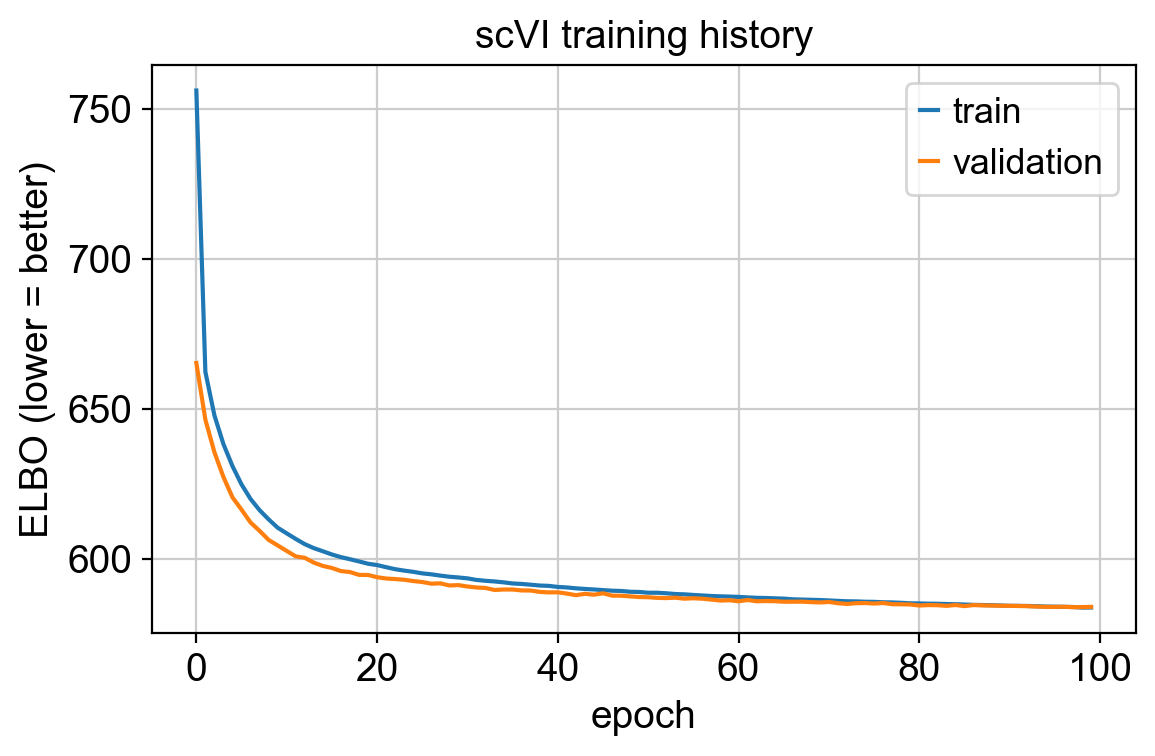

In [6]:
# Plot ELBO history (only available when the model was trained this session,
# not when loaded from a checkpoint).
hist = getattr(model, "history", None)
have_history = hist is not None and len(hist) > 0 and "elbo_train" in hist

if have_history:
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.plot(hist["elbo_train"], label="train", lw=1.5)
    if "elbo_validation" in hist:
        ax.plot(hist["elbo_validation"], label="validation", lw=1.5)
    ax.set_xlabel("epoch")
    ax.set_ylabel("ELBO (lower = better)")
    ax.set_title("scVI training history")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / "elbo_history.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Training history unavailable (model loaded from checkpoint).")
    print("See figures/elbo_history.png from the original training run.")

## 5. Extract latent representation + run UMAP

Once trained, ask the encoder to project every cell into the 10-dim latent
space. Then build a KNN graph on the latent space and run UMAP for
visualization.

In [7]:
adata.obsm["X_scVI"] = model.get_latent_representation()
print(f"adata.obsm['X_scVI'] shape: {adata.obsm['X_scVI'].shape}")

# Neighbors + UMAP on the scVI latent space
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=15)
sc.tl.umap(adata, min_dist=0.3)
print(f"UMAP done. adata.obsm['X_umap'] shape: {adata.obsm['X_umap'].shape}")

adata.obsm['X_scVI'] shape: (92013, 10)
computing neighbors
    finished (0:01:05)
computing UMAP
    finished (0:01:36)
UMAP done. adata.obsm['X_umap'] shape: (92013, 2)


## 6. Visual evaluation

Three UMAPs side by side. What we want to see:

- **Colored by study**: cells from all 19 studies should be visually
  intermixed — no single study isolated in a corner. This is the "did scVI
  work" check.
- **Colored by cell_type_major**: clear, biologically interpretable clusters
  (T cells, B cells, epithelial, myeloid, endothelial). This is the
  "biology preserved" check.
- **Colored by disease**: LUAD / LUSC / normal should overlap in cell-type
  space but may show some compositional differences (different cell-type
  proportions in different disease groups — that's the signal notebook 04
  will exploit).

In [8]:
# UMAP by study (batch-mixing check) — side legend for all 19 studies
sc.pl.umap(adata, color="study", frameon=False, show=False,
           save="_by_study.png", size=4, legend_fontsize=6)
plt.show()

In [9]:
# UMAP by disease
sc.pl.umap(adata, color="disease", frameon=False, show=False,
           save="_by_disease.png", size=4)
plt.show()

In [10]:
# UMAP by cell_type_major (biology check)
sc.pl.umap(adata, color="cell_type_major", frameon=False, show=False,
           save="_by_cell_type_major.png", size=4)
plt.show()

## 7. Quantitative integration metrics

Two silhouette scores tell the integration story:

- **Cell-type silhouette on `X_scVI`** vs **on log-normalized space (PCA)** —
  should *increase* after integration. Cells of the same type cluster tighter
  in the corrected space.
- **Study silhouette on `X_scVI`** vs **on PCA** — should *decrease*. Cells
  from different studies are no longer separated by lab-of-origin.

Computed on a 10,000-cell subsample for speed (full computation is O(n²)).

In [11]:
from sklearn.metrics import silhouette_score

# Subsample for tractable silhouette computation
rng = np.random.default_rng(42)
n_sub = min(10_000, adata.n_obs)
idx = rng.choice(adata.n_obs, size=n_sub, replace=False)

# PCA on log-normalized .X for the "before integration" baseline
sc.tl.pca(adata, n_comps=50)
X_pca = adata.obsm["X_pca"][idx]
X_scvi = adata.obsm["X_scVI"][idx]

labels_celltype = adata.obs["cell_type_major"].astype(str).values[idx]
labels_study = adata.obs["study"].astype(str).values[idx]

metrics = {
    "cell_type_silhouette_pca":   silhouette_score(X_pca,  labels_celltype, sample_size=5000, random_state=42),
    "cell_type_silhouette_scvi":  silhouette_score(X_scvi, labels_celltype, sample_size=5000, random_state=42),
    "study_silhouette_pca":       silhouette_score(X_pca,  labels_study,    sample_size=5000, random_state=42),
    "study_silhouette_scvi":      silhouette_score(X_scvi, labels_study,    sample_size=5000, random_state=42),
}
df = pd.DataFrame([metrics]).T.rename(columns={0: "value"})
df["interpretation"] = [
    "before — cell-type clustering",
    "after — cell-type clustering (want HIGHER)",
    "before — study clustering",
    "after — study clustering (want LOWER)",
]
print(df.round(4))

df.to_csv(FIG_DIR / "integration_metrics.csv")
print(f"\nWrote {relpath(FIG_DIR / 'integration_metrics.csv')}")

computing PCA
    with n_comps=50
    finished (0:00:05)
                            value                              interpretation
cell_type_silhouette_pca   0.0963               before — cell-type clustering
cell_type_silhouette_scvi  0.1344  after — cell-type clustering (want HIGHER)
study_silhouette_pca      -0.0181                   before — study clustering
study_silhouette_scvi     -0.0692       after — study clustering (want LOWER)

Wrote figures\integration_metrics.csv


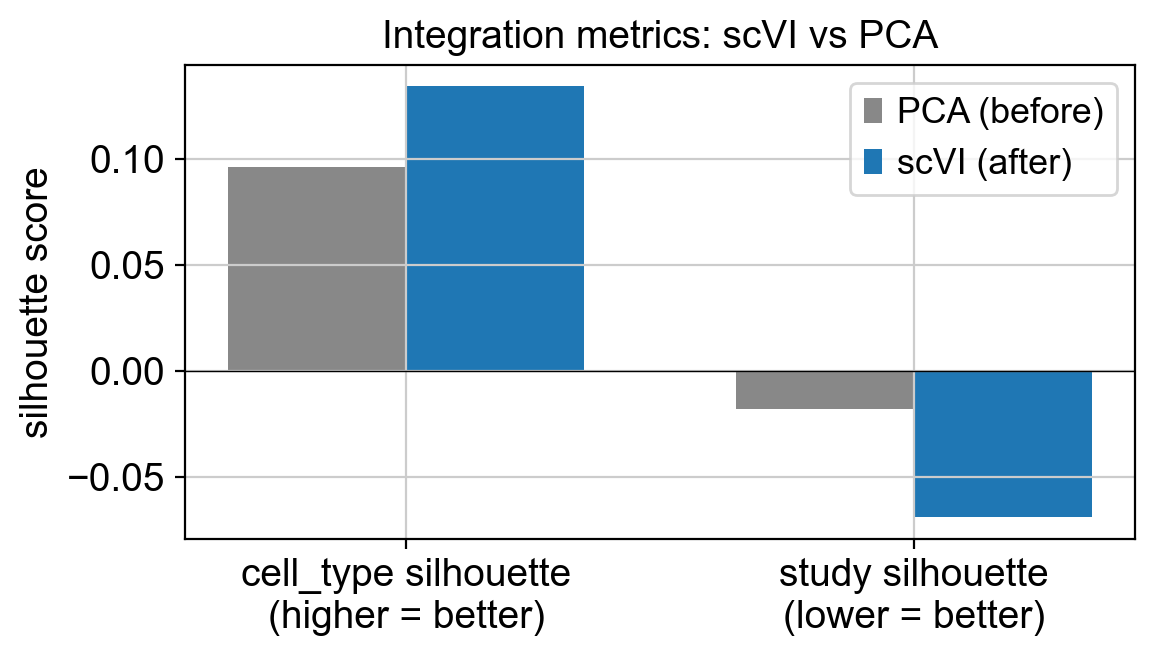

In [12]:
# Quick visual of the metrics shift
fig, ax = plt.subplots(figsize=(6, 3.5))
labels = ["cell_type silhouette\n(higher = better)", "study silhouette\n(lower = better)"]
before = [metrics["cell_type_silhouette_pca"],  metrics["study_silhouette_pca"]]
after  = [metrics["cell_type_silhouette_scvi"], metrics["study_silhouette_scvi"]]
x = np.arange(len(labels))
w = 0.35
ax.bar(x - w/2, before, w, label="PCA (before)", color="#888")
ax.bar(x + w/2, after,  w, label="scVI (after)", color="#1f77b4")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("silhouette score")
ax.set_title("Integration metrics: scVI vs PCA")
ax.legend()
ax.axhline(0, color="black", lw=0.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "integration_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Save checkpoint + integrated AnnData

The model checkpoint lets us re-load without re-training (instantaneous).
The integrated AnnData carries `obsm["X_scVI"]` and `obsm["X_umap"]` so
notebook 03 can pick up where this leaves off.

In [13]:
# The model checkpoint was already saved in section 4. Here we save the
# integrated AnnData that notebook 03 picks up.
out_path = save_adata(adata, "processed/luca_integrated.h5ad")
print(f"Saved integrated AnnData to {relpath(out_path)}")
print(f"  size: {out_path.stat().st_size / 1e6:.0f} MB")
print(f"  obsm: {list(adata.obsm.keys())}")
print(f"  model checkpoint: {relpath(MODEL_DIR)}")

Saved integrated AnnData to data\processed\luca_integrated.h5ad
  size: 1163 MB
  obsm: ['X_scVI', 'X_umap', 'X_pca']
  model checkpoint: models\scvi_luca


## Summary - Phase 2 complete

- Loaded notebook 01's filtered AnnData (`.X` log-normalized, `layers["counts"]` raw)
- Cast counts to int32 and subset to 2,000 HVGs for scVI training
- Trained scVI with `study` as the batch covariate, `n_latent=10`
- Extracted the latent embedding and ran UMAP
- Visually confirmed batch mixing (UMAP by study) and biological clustering (UMAP by cell type)
- Quantitatively confirmed cell-type silhouette up and study silhouette down vs PCA
- Saved model checkpoint and integrated AnnData

**Next:** [`03_cell_type_annotation.ipynb`](03_cell_type_annotation.ipynb) - Leiden clustering on `X_scVI`, marker-gene scoring for major cell types, benchmark against LuCA's published `cell_type_major` labels.